In [61]:
import requests
import pandas as pd
import numpy as np
import re
import time
from bs4 import BeautifulSoup
from sklearn.cluster import KMeans
import hdbscan
import umap
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Fetching books from Goodreads by scrapping for 12 generes

In [ ]:
def scrape_goodreads_shelf(shelf_name, pages=1):

    books = []

    BASE_URL = f"https://www.goodreads.com/shelf/show/{shelf_name}?page={{}}"

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0"
    })

    author_cache = {}

    for page in range(1, pages + 1):

        print(f"Scraping page {page}")

        try:
            res = session.get(BASE_URL.format(page), timeout=20)
            res.raise_for_status()
        except Exception as e:
            print(f"Failed page {page}: {e}")
            continue

        soup = BeautifulSoup(res.text, "html.parser")
        book_items = soup.select(".elementList")

        print(f"Found {len(book_items)} books")
        
        for item in book_items:

            try:
                book_tag = item.select_one(".bookTitle")
                author_tag = item.select_one(".authorName")

                if not book_tag or not author_tag:
                    print("no tag")
                    continue

                title = book_tag.get_text(strip=True)
                author = author_tag.get_text(strip=True)
                author_link = author_tag["href"]

                img_tag = item.select_one("img")
                img = img_tag["src"] if img_tag else None

                info_tag = item.select_one(".greyText.smallText")
                info = info_tag.get_text(" ", strip=True) if info_tag else ""

                # ---------------------------
                # Book stats
                # ---------------------------
                rating_match = re.search(r"avg rating\s*([\d.]+)", info)
                rating = float(rating_match.group(1)) if rating_match else None

                ratings_count_match = re.search(r"([\d,]+)\s+ratings", info)
                no_of_ratings = (
                    int(ratings_count_match.group(1).replace(",", ""))
                    if ratings_count_match else None
                )

                year_match = re.search(r"published\s+(\d{4})", info)
                published_year = int(year_match.group(1)) if year_match else None

                # ---------------------------
                # Book page
                # ---------------------------
                book_link = "https://www.goodreads.com" + book_tag["href"]

                description = ""
                genres = []
                print("before desc")
                try:
                    headers = {
                        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
                    }
                    book_res = session.get(book_link, headers=headers,timeout=20)
                    book_soup = BeautifulSoup(book_res.text, "html.parser")
                    print(book_res.status_code)
                    print(book_res.text[:2000])
                    print("book_link",book_link)
                    # description
                    desc_span = book_soup.find("span", class_="Formatted")
                    print("span",desc_span)
                    if desc_span:
                        description = desc_span.get_text(
                            separator=" ",
                            strip=True
                        )

                    # genres
                    genre_items = book_soup.select(
                        ".BookPageMetadataSection__genreButton"
                    )

                    for g in genre_items:
                        label = g.select_one(".Button__labelItem")
                        if label:
                            genres.append(label.get_text(strip=True))

                except Exception:
                    pass

                books.append({
                    "title": title,
                    "author": author,
                    "rating": rating,
                    "image": img,
                    "author_link": author_link,
                    "description": description,
                    "no_of_ratings": no_of_ratings,
                    "published_year": published_year,
                    "genres": genres
                })

            except Exception as e:
                print("Error:", e)
                continue

        time.sleep(1)

    return pd.DataFrame(books)

Scrapping books of diff genere with some other information

In [85]:
df_india = scrape_goodreads_shelf("india",pages=10)

df_fiction = scrape_goodreads_shelf("fiction",pages=10)

df_fantacy = scrape_goodreads_shelf("fantacy",pages=10)

df_history = scrape_goodreads_shelf("history",pages=10)

df_philosophy = scrape_goodreads_shelf("philosophy",pages=10)

df_religion = scrape_goodreads_shelf("religion",pages=10)

df_romance = scrape_goodreads_shelf("romance",pages=10)

df_thriller = scrape_goodreads_shelf("thriller",pages=10)

df_science = scrape_goodreads_shelf("science",pages=10)

df_travel = scrape_goodreads_shelf("travel",pages=10)

df_comics = scrape_goodreads_shelf("comics",pages=10)

df_adventure = scrape_goodreads_shelf("adventure",pages=10)

Scraping page 1
Found 52 books
before desc
book_link https://www.goodreads.com/book/show/9777.The_God_of_Small_Things
span None
before desc
book_link https://www.goodreads.com/book/show/1768603.The_White_Tiger
span None
before desc
book_link https://www.goodreads.com/book/show/14836.Midnight_s_Children
span None
before desc
book_link https://www.goodreads.com/book/show/5211.A_Fine_Balance
span None
before desc
book_link https://www.goodreads.com/book/show/33917.The_Namesake
span None
before desc
book_link https://www.goodreads.com/book/show/11869272-behind-the-beautiful-forevers
span None
before desc
book_link https://www.goodreads.com/book/show/5439.Interpreter_of_Maladies
span None
before desc
book_link https://www.goodreads.com/book/show/33600.Shantaram
span None
before desc
book_link https://www.goodreads.com/book/show/180357146-the-covenant-of-water
span None
before desc
book_link https://www.goodreads.com/book/show/4214.Life_of_Pi
span None
before desc
book_link https://www.goodr

In [77]:
df_fiction.to_csv('df_indian_fiction.csv', index=False)
df_science.to_csv('df_indian_science.csv', index=False)
df_adventure.to_csv('df_indian_adventure.csv', index=False)
df_comics.to_csv('df_indian_comics.csv', index=False)
df_fantacy.to_csv('df_indian_fantacy.csv', index=False)
df_history.to_csv('df_indian_history.csv', index=False)
df_india.to_csv('df_indian_india.csv', index=False)
df_philosophy.to_csv('df_indian_philosophy.csv', index=False)
df_religion.to_csv('df_indian_religion.csv', index=False)
df_romance.to_csv('df_indian_romance.csv', index=False)
df_thriller.to_csv('df_indian_thriller.csv', index=False)
df_travel.to_csv('df_indian_travel.csv', index=False)

In [78]:
#df_fiction = pd.read_csv("df_indian_fiction.csv")
df_science = pd.read_csv("df_indian_science.csv")
df_adventure = pd.read_csv("df_indian_adventure.csv")
df_comics = pd.read_csv("df_indian_comics.csv")
df_fantasy = pd.read_csv("df_indian_fantacy.csv")
df_history = pd.read_csv("df_indian_history.csv")
df_india = pd.read_csv("df_indian_india.csv")
df_philosophy = pd.read_csv("df_indian_philosophy.csv")
df_religion = pd.read_csv("df_indian_religion.csv")
df_romance = pd.read_csv("df_indian_romance.csv")
df_thriller = pd.read_csv("df_indian_thriller.csv")
df_travel = pd.read_csv("df_indian_travel.csv")

df_gr_final = pd.concat([
    df_fiction,
    df_science,
    df_adventure,
    df_comics,
    df_fantacy,
    df_history,
    df_india,
    df_philosophy,
    df_religion,
    df_romance,
    df_thriller,
    df_travel
], ignore_index=True)

df_gr_final.to_csv('df_gr_final.csv', index=False)

In [68]:
df_gr_final = pd.read_csv("df_gr_final.csv")
df_gr_final.shape

(5500, 10)

In [79]:
df_gr_final

,title,author,rating,image,author_link,description,no_of_ratings,published_year,genres
0,1984 (Paperback),George Orwell,4.20,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/3706.Geo...,,5641508.0,1948.0,[]
1,To Kill a Mockingbird (Paperback),Harper Lee,4.26,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/1825.Har...,,7026540.0,1960.0,[]
2,The Great Gatsby (Paperback),F. Scott Fitzgerald,3.93,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/3190.F_S...,,6050905.0,1925.0,[]
3,Animal Farm (Mass Market Paperback),George Orwell,4.03,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/3706.Geo...,,4703790.0,1945.0,[]
4,Harry Potter and the Philosopher's Stone (Harr...,J.K. Rowling,4.47,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/1077326....,,11646021.0,1997.0,[]
...,...,...,...,...,...,...,...,...,...
5945,Tracks: A Woman's Solo Trek Across 1700 Miles ...,Robyn Davidson,3.93,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/44844.Ro...,NaN,18042.0,1980.0,[]
5946,Getting Stoned with Savages: A Trip Through th...,J. Maarten Troost,3.86,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/7209.J_M...,NaN,14110.0,2006.0,[]
5947,World Travel: An Irreverent Guide (Hardcover),Anthony Bourdain,3.63,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/1124.Ant...,NaN,13438.0,2021.0,[]
5948,Kon-Tiki (Paperback),Thor Heyerdahl,4.16,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/author/show/18206.Th...,NaN,25536.0,1948.0,[]


Fetching more books with openlibrary API

In [5]:
def safe_get(url, retries=3):
    for _ in range(retries):
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            return r.json()
        except:
            time.sleep(1)
    return None


def fetch_openlibrary_books(subjects, limit=50):
    """
    Fetch books from OpenLibrary by subject(s)

    Parameters:
        subjects (str or list): e.g. "fiction" or ["fiction", "romance"]
        limit (int): number of books per subject

    Returns:
        pd.DataFrame
    """

    if isinstance(subjects, str):
        subjects = [subjects]

    books = []
    seen = set()

    for subject in subjects:

        url = f"https://openlibrary.org/subjects/{subject}.json?limit={limit}"
        data = safe_get(url)

        if not data or "works" not in data:
            continue

        for work in data["works"]:

            key = work.get("key")
            if not key or key in seen:
                continue
            seen.add(key)

            title = work.get("title")

            # ---------------- IMAGE ----------------
            cover_id = work.get("cover_id")
            image = f"https://covers.openlibrary.org/b/id/{cover_id}-L.jpg" if cover_id else None

            # ---------------- AUTHOR ----------------
            authors = work.get("authors", [])
            author_name = authors[0].get("name") if authors else None

            # ---------------- GENRES ----------------
            genres = work.get("subject", []) or []

            # ---------------- PUBLISHED YEAR ----------------
            published_year = work.get("first_publish_year")

            author_link = None
            description = ""

            # ---------------- WORK DETAILS ----------------
            work_data = safe_get(f"https://openlibrary.org{key}.json")

            if work_data:

                desc = work_data.get("description")
                if isinstance(desc, dict):
                    description = desc.get("value", "")
                elif isinstance(desc, str):
                    description = desc

                if not published_year:
                    published_year = work_data.get("first_publish_date")
                    if published_year:
                        published_year = published_year[:4]

                authors_data = work_data.get("authors", [])
                if authors_data:
                    try:
                        author_key = authors_data[0]["author"]["key"]
                        author_link = "https://openlibrary.org" + author_key
                    except:
                        author_link = None

            books.append({
                "book_name": title,
                "author": author_name,
                "published_year": published_year,
                "image": image,
                "author_link": author_link,
                "description": description,
                "genres": genres
            })

            time.sleep(0.3)  # avoid rate limits

    return pd.DataFrame(books)

In [6]:
df_api_india = fetch_openlibrary_books("india", limit=500)
df_api_fiction = fetch_openlibrary_books("fiction", limit=500)
df_api_adventure = fetch_openlibrary_books("adventure", limit=300)

print("Three genere's done")

df_api_comics = fetch_openlibrary_books("comics", limit=300)
df_api_fantasy = fetch_openlibrary_books("fantasy", limit=300)
df_api_history = fetch_openlibrary_books("history", limit=300)
print("Six genere's done")

df_api_philosophy = fetch_openlibrary_books("philosophy", limit=300)
df_api_religion = fetch_openlibrary_books("religion", limit=300)
df_api_romance = fetch_openlibrary_books("romance", limit=300)
print("Nine genere's done")

df_api_science = fetch_openlibrary_books("science", limit=300)
df_api_thriller = fetch_openlibrary_books("thriller", limit=300)
df_api_travel = fetch_openlibrary_books("travel", limit=300)
print("Twelve genere's done")

df_api_final = pd.concat([
 df_api_fiction,
    df_api_science,
    df_api_adventure,
    df_api_comics,
    df_api_fantasy,
    df_api_history,
    df_api_india,
    df_api_philosophy,
    df_api_religion,
    df_api_romance,
    df_api_thriller,
    df_api_travel
], ignore_index=True)

df_api_final.to_csv('df_api_final.csv', index=False)

Three genere's done
Six genere's done
Nine genere's done
Twelve genere's done


In [ ]:
df_fiction.to_csv('df_indian_fiction.csv', index=False)
df_science.to_csv('df_indian_science.csv', index=False)
df_adventure.to_csv('df_indian_adventure.csv', index=False)
df_comics.to_csv('df_indian_comics.csv', index=False)
df_fantacy.to_csv('df_indian_fantacy.csv', index=False)
df_history.to_csv('df_indian_history.csv', index=False)
df_india.to_csv('df_indian_india.csv', index=False)
df_philosophy.to_csv('df_indian_philosophy.csv', index=False)
df_religion.to_csv('df_indian_religion.csv', index=False)
df_romance.to_csv('df_indian_romance.csv', index=False)
df_thriller.to_csv('df_indian_thriller.csv', index=False)
df_travel.to_csv('df_indian_travel.csv', index=False)

Merge books that we got from scrapping and from API

In [4]:
#Goodreads → standard format
#clean duplicates
df_gr_final = pd.read_csv("df_gr_final.csv")
df_gr_final = df_gr_final.drop_duplicates(subset=["title", "author"])
df_gr = df_gr_final.copy()
df_gr["source"] = "goodreads"

#OpenLibrary → standard format
df_api_final = pd.read_csv("df_api_final.csv")
df_api_final = df_api_final.drop_duplicates(subset=["book_name", "author"])
df_ol = df_api_final.copy()
df_ol = df_ol.rename(columns={
    "book_name": "title"
})

df_ol["rating"] = None
df_ol["no_of_ratings"] = None
df_ol["source"] = "openlibrary"

#final columns
final_cols = [
    "title",
    "author",
    "rating",
    "no_of_ratings",
    "published_year",
    "image",
    "author_link",
    "description",
    "genres",
    "source"
]

df_ol = df_ol.reindex(columns=final_cols)
df_gr = df_gr.reindex(columns=final_cols)

#merge datasets
df_final = pd.concat([df_ol, df_gr], ignore_index=True)

#clean missing values
df_final["rating"] = df_final["rating"].fillna(0)
df_final["no_of_ratings"] = df_final["no_of_ratings"].fillna(0)

#final result
print(df_final.head(5))
print("Total books:", len(df_final))

                              title           author  rating  no_of_ratings  \
0               Pride and Prejudice      Jane Austen     0.0            0.0   
1  Alice's Adventures in Wonderland    Lewis Carroll     0.0            0.0   
2                 A Christmas Carol  Charles Dickens     0.0            0.0   
3        The Picture of Dorian Gray      Oscar Wilde     0.0            0.0   
4                 Wuthering Heights    Emily Brontë     0.0            0.0   

   published_year                                              image  \
0          1813.0  https://covers.openlibrary.org/b/id/14348537-L...   
1          1865.0  https://covers.openlibrary.org/b/id/10527843-L...   
2          1843.0  https://covers.openlibrary.org/b/id/12875748-L...   
3          1890.0  https://covers.openlibrary.org/b/id/14314858-L...   
4          1846.0  https://covers.openlibrary.org/b/id/12818862-L...   

                                author_link  \
0  https://openlibrary.org/authors/OL21594A  

C:\Users\advik\AppData\Local\Temp\ipykernel_20764\4079103897.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_ol, df_gr], ignore_index=True)


Doing EDA on df_final

In [5]:
df_final.isnull().sum()


title                0
author              30
rating               0
no_of_ratings        0
published_year      63
image              203
author_link         34
description       1320
genres               0
source               0
dtype: int64

In [6]:
(df_final['description'].isna().sum() / len(df_final)) * 100

np.float64(33.53658536585366)

In [7]:
type(df_final['genres'].iloc[0])

str

In [8]:
import ast

df_final['genres'] = df_final['genres'].apply(ast.literal_eval)
import ast
type(df_final['genres'].iloc[0])

list

In [9]:
df_final['num_genres'] = df_final['genres'].apply(len)

df_final['num_genres'].describe()

count    3936.000000
mean       20.096037
std        21.662654
min         0.000000
25%         7.000000
50%        14.000000
75%        26.000000
max       272.000000
Name: num_genres, dtype: float64

In [10]:
df_final["genres_clean"] = df_final["genres"].apply(
    lambda x: x[:20] if isinstance(x, list) else x
)

In [11]:
df_final = df_final[df_final["num_genres"] > 0]

In [12]:
df_final['genres'].head()

0    [Fiction, Romance, Historical, Regency, Britis...
1    [Alice (fictitious character : carroll), ficti...
2    [Children's fiction, Toy and movable books, Ch...
3    [British and irish fiction (fictional works by...
4    [form:novel, genre:tragedy, genre:gothic, Brit...
Name: genres, dtype: object

In [13]:
df_final[df_final["num_genres"] > 50][["title", "num_genres"]]

,title,num_genres
0,Pride and Prejudice,95
1,Alice's Adventures in Wonderland,176
2,A Christmas Carol,186
3,The Picture of Dorian Gray,66
4,Wuthering Heights,119
...,...,...
3246,Novels (Adventures of Huckleberry Finn / Adven...,55
3256,"Eat, Pray, Love",61
3278,Department of Energy,88
3284,Ernst Ludwig Kirchner,68


In [14]:
df_final["genre_text"] = df_final["genres_clean"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

In [29]:
df_final = df_final.reset_index(drop=True)

In [30]:
import re

def clean_title(title):
    if pd.isna(title):
        return None

    # extract inside parentheses if exists
    match = re.search(r"\((.*?)\)", title)
    if match:
        title = match.group(1)

    # remove volume / issue noise
    title = re.sub(r"\b\d+\s*/\s*\d+\b", "", title)
    title = re.sub(r"\b\d+\s*(issues|volumes?|parts?)\b", "", title, flags=re.I)
    title = re.sub(r"in two volumes?", "", title, flags=re.I)

    # split multi-books and take first
    parts = re.split(r"\s*/\s*", title)
    title = parts[0]

    # remove common edition tags in parentheses
    title = re.sub(r"\s*\((hardcover|paperback|kindle edition|ebook|audio book|audiobook)\)", "",
                   title, flags=re.I)

    # remove leftover extra spaces
    title = re.sub(r"\s+", " ", title).strip()

    return re.sub(r"\s+", " ", title).strip(" .,-")

df_final["title_clean"] = df_final["title"].apply(clean_title)

In [31]:
def clean_genres(genres, max_len=20):
    if not isinstance(genres, list):
        return []

    # remove duplicates while preserving order
    seen = set()
    cleaned = []

    for g in genres:
        g = str(g).strip().lower()
        if g and g not in seen:
            cleaned.append(g)
            seen.add(g)

    return cleaned[:max_len]

df_final["genres_clean"] = df_final["genres"].apply(clean_genres)

In [32]:
df_final = df_final[
    (df_final["title"].notna()) &
    (df_final["num_genres"] > 0)
]

In [33]:
#convert year which is float to int
df_final["published_year"] = df_final["published_year"].astype("Int64")

df_final['description'] = df_final['description'].fillna('')


Do clustering using K-means

In [34]:
#Create a text feature
df_final["content"] = (
    df_final["title_clean"].astype(str).fillna("") + " " +
    df_final["author"].fillna("") + " " +
    df_final["description"].fillna("") + " " +
    df_final["genres_clean"].apply(lambda x: " ".join(x))
)

#Convert text to TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=6000
)

X = vectorizer.fit_transform(df_final["content"])

print(X.shape)

#Run K-Means
scores = []


kmeans = KMeans(n_clusters=9, random_state=42)
df_final["cluster"] = kmeans.fit_predict(X)
score = silhouette_score(X, df_final["cluster"])
scores.append(score)

print(f"Score:{score:.3f}")

#Inspect clusters
for i in range(5):
    print(f"\nCLUSTER {i}")
    print(df_final[df_final["cluster"] == i]["title"].head(10))

(3584, 6000)
Score:0.013

CLUSTER 0
5     Adventures of Huckleberry Finn
8                             Hamlet
9                               Emma
17                           Macbeth
18                Gulliver's Travels
19              The Call of the Wild
20                         King Lear
25         A Midsummer Night's Dream
26                Great Expectations
27                     Julius Caesar
Name: title, dtype: object

CLUSTER 1
230                                          The Alhambra
276                                           Roughing It
330               The sketch-book of Geoffrey Crayon, Esq
506     The principall navigations, voiages, and disco...
641                                 Far away and long ago
989                  Advances in spatio-temporal analysis
1018                               Tourism and innovation
1019                      Teaching and Learning Geography
1031          The advanced econometrics of tourism demand
1046                        Progre

Visualize with PCA

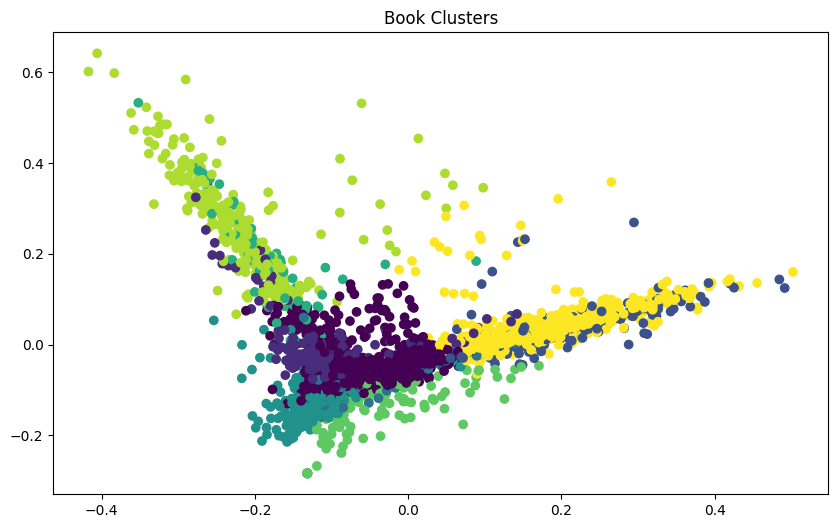

In [35]:
from sklearn.decomposition import PCA

X_dense = X.toarray()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_final["cluster"]
)

plt.title("Book Clusters")
plt.show()

As silhouette_score is very low now tring to cluster using HDBSCAN

In [36]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=10,
    random_state=42
)

X_reduced = reducer.fit_transform(X)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean'
)

labels = clusterer.fit_predict(X_reduced)
df_final["cluster"] = labels



mask = df_final["cluster"] != -1

score = silhouette_score(
    X_reduced[mask],
    df_final.loc[mask, "cluster"]
)

print(score)

c:\Users\advik\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [ ]:
valid_labels = df_final.loc[mask, "cluster"]

if len(set(valid_labels)) > 1:
    score = silhouette_score(X_reduced[mask], valid_labels)
    print(score)
else:
    print("Not enough clusters for silhouette score")

0.5654921531677246


In [37]:
def recommend(book_idx, top_n=5):
    cluster = df_final.loc[book_idx, "cluster"]

    candidates = df_final[
        df_final["cluster"] == cluster
    ].index.to_numpy()

    # remove the queried book itself
    candidates = candidates[candidates != book_idx]

    sims = cosine_similarity(
        X[book_idx].reshape(1, -1),
        X[candidates]
    )[0]

    top_idx = np.argsort(sims)[::-1][:top_n]

    return df_final.loc[candidates[top_idx], ["title", "cluster"]]

def get_book_idx(title):
    return df_final[df_final["title"] == title].index[0]

title = "The Housemaid (The Housemaid, #1)"
book_idx = get_book_idx(title)

recommendations = recommend(book_idx, top_n=10)
print(recommendations)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [38]:
def get_book_idx(title):
    match = df_final[
        df_final["title"].str.lower() == title.lower()
    ]

    if len(match) == 0:
        return None

    return match.index[0]

def recommend(title, top_n=5):

    book_idx = get_book_idx(title)
    cluster = df_final.loc[book_idx, "cluster"]

    candidates = df_final[
        df_final["cluster"] == cluster
    ].index.to_numpy()

    candidates = candidates[candidates != book_idx]

    sims = cosine_similarity(
        X[book_idx].reshape(1, -1),
        X[candidates]
    )[0]

    top_idx = np.argsort(sims)[::-1][:top_n]

    result = df_final.loc[
        candidates[top_idx],
        ["title", "author", "rating"]
    ].copy()

    result["similarity"] = sims[top_idx]

    return result.sort_values(
        "similarity",
        ascending=False
    )

In [47]:
recommend("A Christmas Carol",5)

,title,author,rating,similarity
90,The Cricket on the Hearth,Charles Dickens,0.0,0.530124
2419,The story of the other wise man,Henry van Dyke,0.0,0.411696
246,The Chimes,Charles Dickens,0.0,0.304026
443,After London,Richard Jefferies,0.0,0.270664
161,The Turn of the Screw,Henry James,0.0,0.262967


In [26]:
df_final['title'].head(50)

0                                 Pride and Prejudice
1                    Alice's Adventures in Wonderland
2                                   A Christmas Carol
3                          The Picture of Dorian Gray
4                                   Wuthering Heights
5                      Adventures of Huckleberry Finn
6                                     Robinson Crusoe
7                                  The Scarlet Letter
8                                              Hamlet
9                                                Emma
10                                       Oliver Twist
11              Frankenstein or The Modern Prometheus
12                              Sense and Sensibility
13                               A Tale of Two Cities
14                         The Wonderful Wizard of Oz
15                                    Treasure Island
16                                       Little Women
17                                            Macbeth
18                          

In [55]:
import pickle
df_final["cluster"] = labels

model_bundle = {
    "df_final": df_final,
    "X": X
}

with open("book_recommender.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

Get books by author

In [50]:
df_final["description"] = df_final["description"].fillna("")
author_df = df_final.groupby("author")["description"].apply(" ".join)

#Convert authors → embeddings

vectorizer = TfidfVectorizer(stop_words="english")
author_vectors = vectorizer.fit_transform(author_df)

similarity_matrix = cosine_similarity(author_vectors)

author_to_idx = {author: i for i, author in enumerate(author_df.index)}

def get_similar_authors(author_name, top_k):
    top_k = top_k + 1
    if author_name not in author_to_idx:
        return "Author not found"
    
    idx = author_to_idx[author_name]
    scores = similarity_matrix[idx]
    
    top_idx = np.argsort(scores)[::-1][1:top_k+1]
    top_idx = top_idx[1:]
    return list(author_df.index[top_idx])
    

get_similar_authors("J.K. Rowling",5)

def get_top_books(author, top_n=3):
    temp = df_final[df_final["author"] == author]
    
    return (
        temp.sort_values("rating", ascending=False)["title"]
        .head(top_n)
        .tolist()
    )

def recommend_books(author_name, top_k_authors=5, top_n_books=3):
    
    similar_authors = get_similar_authors(author_name, top_k_authors)
    
    if isinstance(similar_authors, str):
        return similar_authors
    
    result = {}
    
    for author in similar_authors:
        result[author] = get_top_books(author, top_n_books)
    
    return result

recommend_books("J.K. Rowling", 5, 3)

{'Rose Macaulay': ['Potterism'],
 'Arthur Hailey': ['Overload'],
 'David Baldacci': ['Saving Faith', 'Last Man Standing', 'Hour Game'],
 'James Fenimore Cooper': ['The Last of the Mohicans',
  'The deerslayer',
  'The Pathfinder'],
 'Rick Riordan': ['The Lost Hero',
  'The Sword of Summer',
  'The Hammer of Thor']}

In [51]:
import numpy as np
import pandas as pd
import joblib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# Prepare data
# -----------------------------

df_final["description"] = df_final["description"].fillna("")

author_df = (
    df_final
    .groupby("author")["description"]
    .apply(" ".join)
)

# -----------------------------
# Load pretrained model
# -----------------------------

model = SentenceTransformer("all-MiniLM-L6-v2")

# -----------------------------
# Create author embeddings
# -----------------------------

author_embeddings = model.encode(
    author_df.tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# -----------------------------
# Similarity matrix
# -----------------------------

similarity_matrix = cosine_similarity(author_embeddings)

# -----------------------------
# Author lookup
# -----------------------------

author_to_idx = {
    author: idx
    for idx, author in enumerate(author_df.index)
}

# -----------------------------
# Similar authors
# -----------------------------

def get_similar_authors(author_name, top_k=5):

    if author_name not in author_to_idx:
        return []

    idx = author_to_idx[author_name]

    scores = similarity_matrix[idx]

    top_idx = np.argsort(scores)[::-1]

    # remove self
    top_idx = top_idx[top_idx != idx]

    # keep top k
    top_idx = top_idx[:top_k]

    return list(author_df.index[top_idx])

# -----------------------------
# Top books
# -----------------------------

def get_top_books(author, top_n=3):

    books = (
        df_final[df_final["author"] == author]
        .sort_values("rating", ascending=False)
        ["title"]
        .drop_duplicates()
        .head(top_n)
        .tolist()
    )

    return books

# -----------------------------
# Final recommendation function
# -----------------------------

def recommend_books(author_name, top_k_authors=5, top_n_books=3):

    similar_authors = get_similar_authors(
        author_name,
        top_k=top_k_authors
    )

    recommendations = {}

    for author in similar_authors:
        recommendations[author] = get_top_books(
            author,
            top_n=top_n_books
        )

    return recommendations

# -----------------------------
# Example
# -----------------------------

print(
    recommend_books(
        "A. R. Mukherjea",
        top_k_authors=5,
        top_n_books=3
    )
)

Batches: 100%|██████████| 63/63 [01:22<00:00,  1.31s/it]


{'Vladimir Torchilin': ['Handbook of Materials for Nanomedicine'], 'Sunita Apte': ['India'], 'Harold MacGrath': ['The Drums of Jeopardy'], 'Harold A. Gould': ['India Votes'], 'Surama Dasgupta': ['Development of moral philosophy in India']}


In [52]:
df_final["description"] = df_final["description"].fillna("")
model = SentenceTransformer("all-MiniLM-L6-v2")

# book embedding
book_embeddings = model.encode(
    df_final["description"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

df_final["embedding"] = list(book_embeddings)

#Build AUTHOR embeddings
author_embeddings = df_final.groupby("author")["embedding"].apply(
    lambda x: np.mean(np.vstack(x), axis=0)
)

#Similarity matrix
author_matrix = np.vstack(author_embeddings.values)
similarity_matrix = cosine_similarity(author_matrix)

#Fast lookup map
author_to_idx = {
    author: idx
    for idx, author in enumerate(author_embeddings.index)
}

#Similar authors function
def get_similar_authors(author_name, top_k=5):

    if author_name not in author_to_idx:
        return []

    idx = author_to_idx[author_name]
    scores = similarity_matrix[idx]

    top_idx = np.argsort(scores)[::-1]
    top_idx = top_idx[top_idx != idx]   # remove self
    top_idx = top_idx[:top_k]

    return list(author_embeddings.index[top_idx])

#Top books per author
def get_top_books(author, top_n=3):

    temp = df_final[df_final["author"] == author]

    return (
        temp.sort_values("rating", ascending=False)["title"]
        .drop_duplicates()
        .head(top_n)
        .tolist()
    )

#Final recommendation system
def recommend_books(author_name, top_k_authors=5, top_n_books=3):

    similar_authors = get_similar_authors(author_name, top_k_authors)

    result = {}

    for author in similar_authors:
        result[author] = get_top_books(author, top_n_books)

    return result

#Test
print(
    recommend_books("J.K. Rowling", 5, 3)
)

Batches: 100%|██████████| 112/112 [02:13<00:00,  1.19s/it]


{'J. K. Rowling': ["Harry Potter and the Philosopher's Stone", 'Harry Potter and the Chamber of Secrets', 'Harry Potter and the Prisoner of Azkaban'], 'Terry Pratchett': ['The Colour of Magic', 'Mort', 'The Light Fantastic'], 'Susan Cooper': ['The dark is rising', 'Over Sea, Under Stone (The Dark Is Rising #1)', 'The Grey King (The Dark is Rising #4)'], 'Rick Riordan': ['The Lost Hero', 'The Sword of Summer', 'The Hammer of Thor'], 'Rose Macaulay': ['Potterism']}


In [53]:
joblib.dump(author_embeddings, "author_embeddings.pkl")
joblib.dump(author_df, "author_df.pkl")
joblib.dump(author_to_idx, "author_to_idx.pkl")
joblib.dump(df_final, "books_df.pkl")
joblib.dump(similarity_matrix, "similarity_matrix.pkl")

['similarity_matrix.pkl']

In [91]:
df_final.head(5)

,title,author,rating,no_of_ratings,published_year,image,author_link,description,genres,source,content,cluster,embedding
0,Pride and Prejudice,Jane Austen,0.0,0.0,1813,https://covers.openlibrary.org/b/id/14348537-L...,https://openlibrary.org/authors/OL21594A,Pride and Prejudice is an 1813 novel of manner...,"['Fiction, Romance, Historical, Regency', 'Bri...",openlibrary,Pride and Prejudice Jane Austen Pride and Prej...,3,"[-0.06527898, -0.005416097, 0.017923353, 0.037..."
1,Alice's Adventures in Wonderland,Lewis Carroll,0.0,0.0,1865,https://covers.openlibrary.org/b/id/10527843-L...,https://openlibrary.org/authors/OL22098A,Alice's Adventures in Wonderland (commonly Ali...,"['Alice (fictitious character : carroll), fict...",openlibrary,Alice's Adventures in Wonderland Lewis Carroll...,2,"[0.12583256, 0.023767073, 0.025469268, 0.06464..."
2,A Christmas Carol,Charles Dickens,0.0,0.0,1843,https://covers.openlibrary.org/b/id/12875748-L...,https://openlibrary.org/authors/OL24638A,A retelling of the story about a miser whose l...,"[""Children's fiction"", 'Toy and movable books'...",openlibrary,A Christmas Carol Charles Dickens A retelling ...,3,"[-0.06422449, 0.06520466, 0.02232255, 0.063761..."
3,The Picture of Dorian Gray,Oscar Wilde,0.0,0.0,1890,https://covers.openlibrary.org/b/id/14314858-L...,https://openlibrary.org/authors/OL20646A,**The Picture of Dorian Gray** is a philosophi...,['British and irish fiction (fictional works b...,openlibrary,The Picture of Dorian Gray Oscar Wilde **The P...,3,"[-0.047704134, 0.113628, 0.057173815, 0.043567..."
4,Wuthering Heights,Emily Brontë,0.0,0.0,1846,https://covers.openlibrary.org/b/id/12818862-L...,https://openlibrary.org/authors/OL24529A,Wuthering Heights is an 1847 novel by Emily Br...,"['form:novel', 'genre:tragedy', 'genre:gothic'...",openlibrary,Wuthering Heights Emily Brontë Wuthering Heig...,3,"[-0.0341087, -0.030990759, -0.010007753, 0.087..."


In [92]:
df_final[df_final["title"].str.contains("Novels", na=False)]

,title,author,rating,no_of_ratings,published_year,image,author_link,description,genres,source,content,cluster,embedding
824,Novels (The Call of the Wild / White Fang),Jack London,0.0,0.0,1962,https://covers.openlibrary.org/b/id/9381751-L.jpg,https://openlibrary.org/authors/OL44633A,"Two classic tales of dogs, one part wolf and o...","['Fiction', 'Wolfdogs', 'Feral dogs', 'Animal ...",openlibrary,Novels (The Call of the Wild / White Fang) Jac...,3,"[0.025261128, -0.027174514, 0.0011352423, 0.09..."
2681,Novels (Emma / Mansfield Park / Northanger Abb...,Jane Austen,0.0,0.0,1818,https://covers.openlibrary.org/b/id/9276728-L.jpg,https://openlibrary.org/authors/OL21594A,Emma\r\nMansfield Park\r\nNorthanger Abbey\r\n...,['British and irish fiction (fictional works b...,openlibrary,Novels (Emma / Mansfield Park / Northanger Abb...,3,"[-0.03161776, -0.07038154, -0.012560105, -0.00..."
2757,Novels (Emma / Lady Susan / Mansfield Park / N...,Jane Austen,0.0,0.0,1966,https://covers.openlibrary.org/b/id/9277892-L.jpg,https://openlibrary.org/authors/OL21594A,Contains:\r\nEmma\r\nLady Susan\r\nMansfield P...,['British and irish fiction (fictional works b...,openlibrary,Novels (Emma / Lady Susan / Mansfield Park / N...,3,"[-0.02348545, -0.059426595, 0.0063699908, -0.0..."
2781,Novels (Pride and Prejudice / Sense and Sensib...,Jane Austen,0.0,0.0,1949,https://covers.openlibrary.org/b/id/12728748-L...,https://openlibrary.org/authors/OL21594A,Contains:\r\n\r\n - [Pride and Prejucice](http...,['British and irish fiction (fictional works b...,openlibrary,Novels (Pride and Prejudice / Sense and Sensib...,3,"[0.014248574, 0.01191131, -0.014061464, -0.009..."
2843,Novels (Agnes Grey / Jane Eyre / Wuthering Hei...,Anne Brontë,0.0,0.0,1947,https://covers.openlibrary.org/b/id/14421819-L...,https://openlibrary.org/authors/OL342487A,The three great novels collected here are set ...,['British and irish fiction (fictional works b...,openlibrary,Novels (Agnes Grey / Jane Eyre / Wuthering Hei...,3,"[-0.00080284185, -0.040641792, -0.011447318, 0..."
3246,Novels (Adventures of Huckleberry Finn / Adven...,Mark Twain,0.0,0.0,1922,https://covers.openlibrary.org/b/id/12374727-L...,https://openlibrary.org/authors/OL18319A,THE ADVENTURES OF TOM SAWYER\r\n\r\nTake a lig...,"['Juvenile works', 'juvenile audience', 'liter...",openlibrary,Novels (Adventures of Huckleberry Finn / Adven...,6,"[-0.119205356, -0.0034534899, -0.054753017, 0...."


In [93]:
pd.set_option("display.max_colwidth", None)

df_final[["title"]].head(20)

,title
0,Pride and Prejudice
1,Alice's Adventures in Wonderland
2,A Christmas Carol
3,The Picture of Dorian Gray
4,Wuthering Heights
5,Adventures of Huckleberry Finn
6,Robinson Crusoe
7,The Scarlet Letter
8,Hamlet
9,Emma


In [54]:
df_final[df_final["title"].str.contains(r"/", na=False)][["title"]]

,title
172,Alice's Adventures in Wonderland / Through the...
524,NASA/DoD aerospace knowledge diffusion researc...
824,Novels (The Call of the Wild / White Fang)
845,El Amo Del Juego/Masters of the Game
1199,Ranma 1/2 (12 Issues)
1292,"/Gæ • ˈräj/, issue @"
1546,Winnie-the-Pooh / The House at Pooh Corner
1567,Animal Farm / Nineteen Eighty-Four
2101,Organisational set-up and functions of the min...
2216,Εὐθύφρων / Κρίτων / Φαίδων / Ἀπολογία Σωκράτους


In [58]:
model_bundle = {
    "df_final": df_final,
    "X": X,
    "author_embeddings": author_embeddings,
    "author_to_idx": author_to_idx,
    "similarity_matrix": similarity_matrix,
}

In [60]:
with open("pickles/full_recommender.pkl", "wb") as f:
    pickle.dump(model_bundle, f)